# Detecting Pneumonia via Anomaly Detection in Chest X-Ray Images

This notebook contains the modeling code for HW3:
1. Autoencoder-based anomaly detection trained only on NORMAL X-ray images.
2. CNN supervised baseline using ResNet18 and EfficientNet.
3. Vision Transformer supervised baseline using timm.
4. Final model comparison graphs and tables.


## 1. Imports and global configuration

In [1]:
!pip install -q timm

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import zipfile
import re
import timm
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import cv2
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    auc,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Dataset paths

Kaggle API setup and dateset download

In [ ]:
# Upload your personal Kaggle API token file (kaggle.json).
# Never commit kaggle.json or its contents to GitHub.
from google.colab import files
files.upload()


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 232MB/s]



In [6]:
with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [9]:
DATA_DIR = "data/chest_xray"

TRAIN_NORMAL_DIR = os.path.join(DATA_DIR, "train", "NORMAL")
TRAIN_PNEUMONIA_DIR = os.path.join(DATA_DIR, "train", "PNEUMONIA")
TEST_NORMAL_DIR = os.path.join(DATA_DIR, "test", "NORMAL")
TEST_PNEUMONIA_DIR = os.path.join(DATA_DIR, "test", "PNEUMONIA")

for folder in [TRAIN_NORMAL_DIR, TRAIN_PNEUMONIA_DIR, TEST_NORMAL_DIR, TEST_PNEUMONIA_DIR]:
    print(folder, "exists:", os.path.exists(folder))

data/chest_xray/train/NORMAL exists: True
data/chest_xray/train/PNEUMONIA exists: True
data/chest_xray/test/NORMAL exists: True
data/chest_xray/test/PNEUMONIA exists: True


In [10]:
def get_image_paths(folder):
    """Return all image paths from a given folder."""
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")

    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".jpeg", ".jpg", ".png"))
    ]


train_normal_paths = get_image_paths(TRAIN_NORMAL_DIR)
train_pneumonia_paths = get_image_paths(TRAIN_PNEUMONIA_DIR)

test_normal_paths = get_image_paths(TEST_NORMAL_DIR)
test_pneumonia_paths = get_image_paths(TEST_PNEUMONIA_DIR)

test_paths = test_normal_paths + test_pneumonia_paths
test_labels = [0] * len(test_normal_paths) + [1] * len(test_pneumonia_paths)

print("Train NORMAL:", len(train_normal_paths))
print("Train PNEUMONIA:", len(train_pneumonia_paths))
print("Test NORMAL:", len(test_normal_paths))
print("Test PNEUMONIA:", len(test_pneumonia_paths))
print("Total test:", len(test_paths))

Train NORMAL: 1341
Train PNEUMONIA: 3875
Test NORMAL: 234
Test PNEUMONIA: 390
Total test: 624


## 3. Dataset class and preprocessing helpers

In [13]:
class XRayDataset(Dataset):
    """
    General dataset class for chest X-ray images.
    labels=None is used for Autoencoder training, because it is trained only on NORMAL images and does not need class labels.
    """
    def __init__(self, file_paths, labels=None, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]

        # Convert all images to grayscale first so the input format is consistent.
        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        # For the autoencoder training set, labels are not needed.
        if self.labels is None:
            return image

        return image, torch.tensor(self.labels[idx], dtype=torch.long)


class ApplyCLAHE:
    def __call__(self, image):
        """
        CLAHE improves local contrast in X-ray images.
        This is useful because X-rays can differ in brightness and contrast.
        """
        img = np.array(image.convert("L"))
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)
        return Image.fromarray(img)


class PadToSquare:
    """
    Keeps aspect ratio instead of stretching the X-ray directly.
    This better matches what we wrote in HW2 about variable image sizes.
    """
    def __call__(self, image):
        w, h = image.size
        size = max(w, h)
        new_image = Image.new("L", (size, size), 0)
        new_image.paste(image, ((size - w) // 2, (size - h) // 2))
        return new_image

## 4. Autoencoder preprocessing

The autoencoder is trained only on NORMAL images. PNEUMONIA images are used only during evaluation.

In [14]:
def extract_normal_person_id(path):
    """
    Extract a rough person/image identifier for NORMAL images.
    This is used to create a safer internal split for calibration.
    """
    filename = os.path.basename(path)
    parts = filename.split("-")
    if len(parts) >= 2:
        return parts[1]
    return filename

In [15]:
# Split NORMAL images into:
# 1. Autoencoder training set
# 2. Calibration set used to estimate normal reconstruction behavior

normal_groups = [extract_normal_person_id(p) for p in train_normal_paths]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, calib_idx = next(gss.split(train_normal_paths, groups=normal_groups))

ae_train_paths = [train_normal_paths[i] for i in train_idx]
ae_calib_paths = [train_normal_paths[i] for i in calib_idx]

print("AE train NORMAL:", len(ae_train_paths))
print("AE calibration NORMAL:", len(ae_calib_paths))

AE train NORMAL: 482
AE calibration NORMAL: 859


In [16]:
# Augmentation is applied only to NORMAL training images.
# Evaluation images must remain unchanged.

ae_train_transform = transforms.Compose([
    ApplyCLAHE(),
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=7),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
    transforms.ToTensor()
])

ae_eval_transform = transforms.Compose([
    ApplyCLAHE(),
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [17]:
ae_train_dataset = XRayDataset(ae_train_paths, transform=ae_train_transform)

ae_calib_dataset = XRayDataset(
    ae_calib_paths,
    labels=[0] * len(ae_calib_paths),
    transform=ae_eval_transform
)

ae_test_dataset = XRayDataset(
    test_paths,
    labels=test_labels,
    transform=ae_eval_transform
)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=32, shuffle=True, num_workers=0)
ae_calib_loader = DataLoader(ae_calib_dataset, batch_size=32, shuffle=False, num_workers=0)
ae_test_loader = DataLoader(ae_test_dataset, batch_size=32, shuffle=False, num_workers=0)

## 5. Autoencoder model

In [18]:
class BottleneckAutoencoder(nn.Module):
  """
  Convolutional Autoencoder with a bottleneck.

  The model is trained only on NORMAL images.
  During evaluation, images that behave differently from the learned normal
  reconstruction distribution are considered anomalous.
  LeakyReLU is used instead of regular ReLU to reduce the risk of "dead" neurons by allowing a small gradient even for negative activations.
  """
  def __init__(self, latent_dim=256):
        super().__init__()

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),   # 224 -> 112
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 112 -> 56
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 56 -> 28
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 28 -> 14
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, stride=2, padding=1), # 14 -> 7
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )

        self.flatten = nn.Flatten()

        # The latent vector forces the model to compress the normal pattern.
        self.fc_enc = nn.Linear(512 * 7 * 7, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 512 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1), # 7 -> 14
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # 14 -> 28
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 28 -> 56
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 56 -> 112
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),    # 112 -> 224
            nn.Sigmoid()
        )

  def forward(self, x):
        z = self.encoder_conv(x)
        z = self.flatten(z)
        z = self.fc_enc(z)
        x_hat = self.fc_dec(z)
        x_hat = x_hat.view(-1, 512, 7, 7)
        return self.decoder(x_hat)

## 6. Train Autoencoder

In [19]:
ae_model = BottleneckAutoencoder(latent_dim=256).to(device)

# L1 is usually more stable than MSE for X-ray reconstruction.
ae_criterion = nn.L1Loss()
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-4, weight_decay=1e-5)

ae_epochs = 30
ae_train_losses = []

for epoch in range(ae_epochs):
    ae_model.train()
    total_loss = 0.0

    for images in ae_train_loader:
        images = images.to(device)

        ae_optimizer.zero_grad()
        outputs = ae_model(images)

        loss = ae_criterion(outputs, images)
        loss.backward()
        ae_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(ae_train_loader)
    ae_train_losses.append(avg_loss)

    print(f"Epoch {epoch + 1}/{ae_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/30, Loss: 0.2305
Epoch 2/30, Loss: 0.1610
Epoch 3/30, Loss: 0.1405
Epoch 4/30, Loss: 0.1205
Epoch 5/30, Loss: 0.1122
Epoch 6/30, Loss: 0.1056
Epoch 7/30, Loss: 0.0997
Epoch 8/30, Loss: 0.0971
Epoch 9/30, Loss: 0.0945
Epoch 10/30, Loss: 0.0917
Epoch 11/30, Loss: 0.0901
Epoch 12/30, Loss: 0.0889
Epoch 13/30, Loss: 0.0871
Epoch 14/30, Loss: 0.0852
Epoch 15/30, Loss: 0.0853
Epoch 16/30, Loss: 0.0824
Epoch 17/30, Loss: 0.0811
Epoch 18/30, Loss: 0.0803
Epoch 19/30, Loss: 0.0793
Epoch 20/30, Loss: 0.0791
Epoch 21/30, Loss: 0.0784
Epoch 22/30, Loss: 0.0772
Epoch 23/30, Loss: 0.0768
Epoch 24/30, Loss: 0.0768
Epoch 25/30, Loss: 0.0754
Epoch 26/30, Loss: 0.0774
Epoch 27/30, Loss: 0.0752
Epoch 28/30, Loss: 0.0736
Epoch 29/30, Loss: 0.0734
Epoch 30/30, Loss: 0.0743


## 7. Evaluate Autoencoder

In [20]:
def get_reconstruction_losses(model, loader):
    """
    Returns reconstruction losses and labels for a given dataset.
    Mean absolute reconstruction error is used as the base score.
    """
    model.eval()
    losses = []
    labels = []

    with torch.no_grad():
        for images, batch_labels in loader:
            images = images.to(device)
            outputs = model(images)

            batch_losses = torch.mean(torch.abs(outputs - images), dim=[1, 2, 3])

            losses.extend(batch_losses.cpu().numpy())
            labels.extend(batch_labels.numpy())

    return np.array(losses), np.array(labels)

In [21]:
calib_losses, _ = get_reconstruction_losses(ae_model, ae_calib_loader)
test_losses, test_y = get_reconstruction_losses(ae_model, ae_test_loader)

normal_mean = calib_losses.mean()
normal_std = calib_losses.std() + 1e-8

# We measure deviation from the normal reconstruction distribution.
# This is safer than assuming pneumonia always has higher reconstruction error.
anomaly_scores = np.abs((test_losses - normal_mean) / normal_std)

raw_auc = roc_auc_score(test_y, test_losses)
inverse_auc = roc_auc_score(test_y, -test_losses)
z_auc = roc_auc_score(test_y, anomaly_scores)

print("Raw reconstruction-loss AUC:", raw_auc)
print("Inverse reconstruction-loss AUC:", inverse_auc)
print("Z-deviation anomaly AUC:", z_auc)

Raw reconstruction-loss AUC: 0.39812623274161735
Inverse reconstruction-loss AUC: 0.6018737672583827
Z-deviation anomaly AUC: 0.5105303528380452


In [22]:
# Threshold is estimated only from NORMAL calibration images.
calib_scores = np.abs((calib_losses - normal_mean) / normal_std)
threshold = np.percentile(calib_scores, 95)

ae_preds = (anomaly_scores > threshold).astype(int)

print("Threshold:", threshold)
print("Precision:", precision_score(test_y, ae_preds))
print("Recall:", recall_score(test_y, ae_preds))
print("F1:", f1_score(test_y, ae_preds))
print("Confusion matrix:")
print(confusion_matrix(test_y, ae_preds))
print(classification_report(test_y, ae_preds, target_names=["NORMAL", "PNEUMONIA"]))

Threshold: 1.9281557
Precision: 0.625
Recall: 0.0641025641025641
F1: 0.11627906976744186
Confusion matrix:
[[219  15]
 [365  25]]
              precision    recall  f1-score   support

      NORMAL       0.38      0.94      0.54       234
   PNEUMONIA       0.62      0.06      0.12       390

    accuracy                           0.39       624
   macro avg       0.50      0.50      0.33       624
weighted avg       0.53      0.39      0.27       624



## 8. Autoencoder diagnostic plots

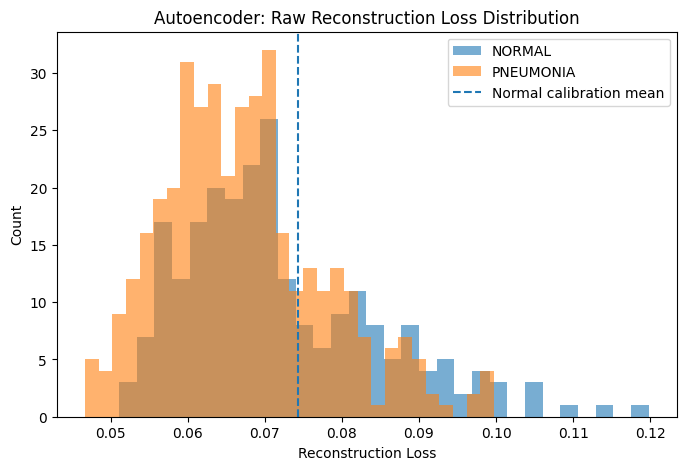

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(test_losses[test_y == 0], bins=30, alpha=0.6, label="NORMAL")
plt.hist(test_losses[test_y == 1], bins=30, alpha=0.6, label="PNEUMONIA")
plt.axvline(normal_mean, linestyle="--", label="Normal calibration mean")
plt.xlabel("Reconstruction Loss")
plt.ylabel("Count")
plt.title("Autoencoder: Raw Reconstruction Loss Distribution")
plt.legend()
plt.show()

The raw reconstruction loss distributions reveal a noticeable overlap between NORMAL and PNEUMONIA images, indicating that reconstruction error alone is not sufficient for a clear class separation.

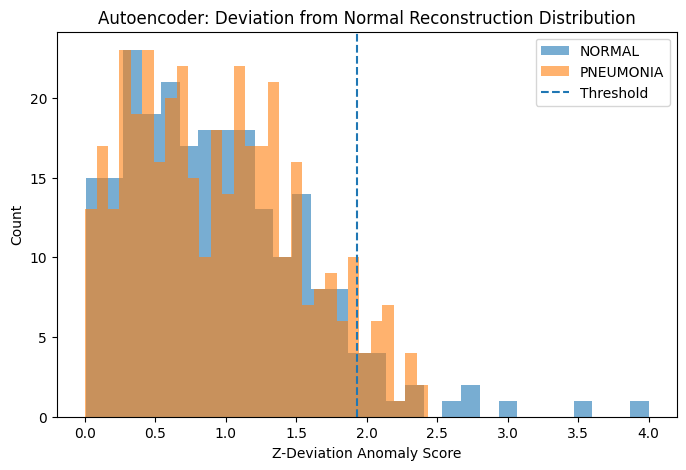

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(anomaly_scores[test_y == 0], bins=30, alpha=0.6, label="NORMAL")
plt.hist(anomaly_scores[test_y == 1], bins=30, alpha=0.6, label="PNEUMONIA")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.xlabel("Z-Deviation Anomaly Score")
plt.ylabel("Count")
plt.title("Autoencoder: Deviation from Normal Reconstruction Distribution")
plt.legend()
plt.show()

The z-deviation anomaly score provides a slightly stronger anomaly signal, but the overlap between the two classes remains significant. These results suggest that pneumonia detection is challenging using reconstruction-based methods alone.


## 9. Supervised CNN / ViT preprocessing and internal validation split

For pretrained CNN/ViT models, grayscale X-rays are replicated to 3 channels because ImageNet models expect RGB input.

In [25]:
def extract_person_id(path):
    """
    Extract patient/person ID from filenames.
    This helps reduce leakage in the internal train/validation split.
    """
    filename = os.path.basename(path)

    # Pneumonia filename example: person1000_bacteria_2931.jpeg
    match = re.search(r"(person\d+)", filename)
    if match:
        return match.group(1)

    # Normal filename example: IM-0115-0001.jpeg
    match = re.search(r"(IM-\d+)", filename)
    if match:
        return match.group(1)

    return filename


train_paths_cls = train_normal_paths + train_pneumonia_paths
train_labels_cls = [0] * len(train_normal_paths) + [1] * len(train_pneumonia_paths)
train_groups_cls = [extract_person_id(p) for p in train_paths_cls]


# Internal validation split from train, because the original validation set has only 16 images.
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
sup_train_idx, sup_val_idx = next(
    gss.split(train_paths_cls, train_labels_cls, groups=train_groups_cls)
)

sup_train_paths = [train_paths_cls[i] for i in sup_train_idx]
sup_train_labels = [train_labels_cls[i] for i in sup_train_idx]

sup_val_paths = [train_paths_cls[i] for i in sup_val_idx]
sup_val_labels = [train_labels_cls[i] for i in sup_val_idx]

print("Supervised train:", len(sup_train_paths), np.bincount(sup_train_labels))
print("Supervised val:", len(sup_val_paths), np.bincount(sup_val_labels))
print("Test:", len(test_paths), np.bincount(test_labels))

Supervised train: 4400 [1141 3259]
Supervised val: 816 [200 616]
Test: 624 [234 390]


In [26]:
# These transforms match ImageNet-pretrained CNN / ViT expectations:
# 3 channels, fixed size, and ImageNet normalization.
supervised_train_transform = transforms.Compose([
    ApplyCLAHE(),
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

supervised_eval_transform = transforms.Compose([
    ApplyCLAHE(),
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [27]:
sup_train_dataset = XRayDataset(
    sup_train_paths,
    labels=sup_train_labels,
    transform=supervised_train_transform
)

sup_val_dataset = XRayDataset(
    sup_val_paths,
    labels=sup_val_labels,
    transform=supervised_eval_transform
)

sup_test_dataset = XRayDataset(
    test_paths,
    labels=test_labels,
    transform=supervised_eval_transform
)

BATCH_SIZE = 32

sup_train_loader = DataLoader(
    sup_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

sup_val_loader = DataLoader(
    sup_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

sup_test_loader = DataLoader(
    sup_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

## 10. Supervised training and evaluation utilities

In [28]:
def get_class_weights(labels):
    """
    Compute class weights to reduce the effect of class imbalance.
    """
    counts = np.bincount(labels)
    total = len(labels)
    weights = total / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32)


class EarlyStopping:
    """
    Keeps the best model according to validation AUC.
    """
    def __init__(self, patience=4):
        self.patience = patience
        self.best_score = -np.inf
        self.counter = 0
        self.best_state = None

    def step(self, score, model):
        if score > self.best_score:
            self.best_score = score
            self.counter = 0
            self.best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            return False

        self.counter += 1
        return self.counter >= self.patience


def evaluate_supervised_model(model, loader, threshold=0.5):
    """
    Evaluate a supervised model and return common classification metrics.
    """
    model.eval()

    probs = []
    true = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            # timm models return Tensor; HuggingFace models may return object.
            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            batch_probs = torch.softmax(outputs, dim=1)[:, 1]

            probs.extend(batch_probs.cpu().numpy())
            true.extend(labels.numpy())

    probs = np.array(probs)
    true = np.array(true)
    preds = (probs >= threshold).astype(int)

    metrics = {
        "auc": roc_auc_score(true, probs),
        "precision": precision_score(true, preds, zero_division=0),
        "recall": recall_score(true, preds, zero_division=0),
        "f1": f1_score(true, preds, zero_division=0),
        "cm": confusion_matrix(true, preds),
        "true": true,
        "probs": probs,
        "preds": preds
    }

    return metrics


def find_best_threshold(y_true, probs, mode="f1"):
    """
    Select classification threshold using validation probabilities.
    For this project, F1 is a reasonable balance between recall and precision.
    """
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t = 0.5
    best_score = -1

    for t in thresholds:
        preds = (probs >= t).astype(int)

        if mode == "recall_f1":
            recall = recall_score(y_true, preds, zero_division=0)
            f1 = f1_score(y_true, preds, zero_division=0)
            score = 0.7 * recall + 0.3 * f1
        else:
            score = f1_score(y_true, preds, zero_division=0)

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score


def train_supervised_model(model, train_loader, val_loader, model_name, epochs=10, lr=1e-4):
    """
    Generic training loop for CNN / EfficientNet / ViT models.
    """
    model = model.to(device)

    class_weights = get_class_weights(sup_train_labels).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    early_stopping = EarlyStopping(patience=4)

    history = {
        "train_loss": [],
        "val_auc": [],
        "val_f1": [],
        "val_recall": []
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs}"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        val_metrics_default = evaluate_supervised_model(model, val_loader, threshold=0.5)
        val_auc = val_metrics_default["auc"]
        val_f1 = val_metrics_default["f1"]
        val_recall = val_metrics_default["recall"]

        scheduler.step(val_auc)

        history["train_loss"].append(avg_train_loss)
        history["val_auc"].append(val_auc)
        history["val_f1"].append(val_f1)
        history["val_recall"].append(val_recall)

        print(
            f"{model_name} | Epoch {epoch+1}/{epochs} | "
            f"Loss={avg_train_loss:.4f} | "
            f"Val AUC={val_auc:.4f} | "
            f"Val F1={val_f1:.4f} | "
            f"Val Recall={val_recall:.4f}"
        )

        if early_stopping.step(val_auc, model):
            print(f"Early stopping triggered for {model_name}")
            break

    if early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)

    return model, history

## 11. Train CNN baseline using ResNet18

In [29]:
cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the ImageNet head with a binary classifier
cnn_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(cnn_model.fc.in_features, 2)
)

cnn_model, cnn_history = train_supervised_model(
    model=cnn_model,
    train_loader=sup_train_loader,
    val_loader=sup_val_loader,
    model_name="CNN ResNet18",
    epochs=10,
    lr=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


CNN ResNet18 Epoch 1/10:   0%|          | 0/138 [00:00<?, ?it/s]

CNN ResNet18 | Epoch 1/10 | Loss=0.1464 | Val AUC=0.9952 | Val F1=0.9794 | Val Recall=0.9659


CNN ResNet18 Epoch 2/10:   0%|          | 0/138 [00:00<?, ?it/s]

...

CNN ResNet18 | Epoch 8/10 | Loss=0.0351 | Val AUC=0.9974 | Val F1=0.9734 | Val Recall=0.9497


CNN ResNet18 Epoch 9/10:   0%|          | 0/138 [00:00<?, ?it/s]

CNN ResNet18 | Epoch 9/10 | Loss=0.0259 | Val AUC=0.9971 | Val F1=0.9835 | Val Recall=0.9692


CNN ResNet18 Epoch 10/10:   0%|          | 0/138 [00:00<?, ?it/s]

CNN ResNet18 | Epoch 10/10 | Loss=0.0192 | Val AUC=0.9976 | Val F1=0.9902 | Val Recall=0.9870
Early stopping triggered for CNN ResNet18


In [30]:
# Select threshold using internal validation set.
cnn_val_metrics = evaluate_supervised_model(cnn_model, sup_val_loader, threshold=0.5)
cnn_best_threshold, cnn_best_val_score = find_best_threshold(
    cnn_val_metrics["true"],
    cnn_val_metrics["probs"],
    mode="f1"
)

print("CNN best validation threshold:", cnn_best_threshold)
print("CNN best validation F1:", cnn_best_val_score)

cnn_test_metrics = evaluate_supervised_model(
    cnn_model,
    sup_test_loader,
    threshold=cnn_best_threshold
)

cnn_true = cnn_test_metrics["true"]
cnn_probs = cnn_test_metrics["probs"]
cnn_preds = cnn_test_metrics["preds"]

print("CNN Test AUC:", cnn_test_metrics["auc"])
print(classification_report(cnn_true, cnn_preds, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))
print("CNN Confusion Matrix:")
print(cnn_test_metrics["cm"])

CNN best validation threshold: 0.055
CNN best validation F1: 0.9894394800974817
CNN Test AUC: 0.9490905106289722
              precision    recall  f1-score   support

      NORMAL       0.99      0.42      0.59       234
   PNEUMONIA       0.74      1.00      0.85       390

    accuracy                           0.78       624
   macro avg       0.87      0.71      0.72       624
weighted avg       0.84      0.78      0.75       624

CNN Confusion Matrix:
[[ 99 135]
 [  1 389]]


## 12. Stronger CNN baseline - EfficientNet-B0

In [31]:
efficientnet_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

efficientnet_model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(efficientnet_model.classifier[1].in_features, 2)
)

efficientnet_model, efficientnet_history = train_supervised_model(
    model=efficientnet_model,
    train_loader=sup_train_loader,
    val_loader=sup_val_loader,
    model_name="CNN EfficientNet-B0",
    epochs=10,
    lr=1e-4
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


CNN EfficientNet-B0 Epoch 1/10:   0%|          | 0/138 [00:00<?, ?it/s]

CNN EfficientNet-B0 | Epoch 1/10 | Loss=0.2219 | Val AUC=0.9953 | Val F1=0.9853 | Val Recall=0.9821


CNN EfficientNet-B0 Epoch 2/10:   0%|          | 0/138 [00:00<?, ?it/s]

...

CNN EfficientNet-B0 | Epoch 8/10 | Loss=0.0239 | Val AUC=0.9987 | Val F1=0.9869 | Val Recall=0.9789


CNN EfficientNet-B0 Epoch 9/10:   0%|          | 0/138 [00:00<?, ?it/s]

CNN EfficientNet-B0 | Epoch 9/10 | Loss=0.0195 | Val AUC=0.9987 | Val F1=0.9886 | Val Recall=0.9821


CNN EfficientNet-B0 Epoch 10/10:   0%|          | 0/138 [00:00<?, ?it/s]

CNN EfficientNet-B0 | Epoch 10/10 | Loss=0.0183 | Val AUC=0.9986 | Val F1=0.9861 | Val Recall=0.9821


In [32]:
efficientnet_val_metrics = evaluate_supervised_model(efficientnet_model, sup_val_loader, threshold=0.5)
efficientnet_best_threshold, efficientnet_best_val_score = find_best_threshold(
    efficientnet_val_metrics["true"],
    efficientnet_val_metrics["probs"],
    mode="f1"
)

print("EfficientNet best validation threshold:", efficientnet_best_threshold)
print("EfficientNet best validation F1:", efficientnet_best_val_score)

efficientnet_test_metrics = evaluate_supervised_model(
    efficientnet_model,
    sup_test_loader,
    threshold=efficientnet_best_threshold
)

eff_true = efficientnet_test_metrics["true"]
eff_probs = efficientnet_test_metrics["probs"]
eff_preds = efficientnet_test_metrics["preds"]

print("EfficientNet Test AUC:", efficientnet_test_metrics["auc"])
print(classification_report(eff_true, eff_preds, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))
print("EfficientNet Confusion Matrix:")
print(efficientnet_test_metrics["cm"])

EfficientNet best validation threshold: 0.175
EfficientNet best validation F1: 0.99185667752443
EfficientNet Test AUC: 0.9573800131492438
              precision    recall  f1-score   support

      NORMAL       0.99      0.48      0.65       234
   PNEUMONIA       0.76      1.00      0.86       390

    accuracy                           0.80       624
   macro avg       0.88      0.74      0.75       624
weighted avg       0.85      0.80      0.78       624

EfficientNet Confusion Matrix:
[[112 122]
 [  1 389]]


## 13. Train Vision Transformer baseline


In [33]:
# ViT is heavier than CNN, so we start with fewer epochs and lower learning rate.
vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2,
    drop_rate=0.2
)

vit_model, vit_history = train_supervised_model(
    model=vit_model,
    train_loader=sup_train_loader,
    val_loader=sup_val_loader,
    model_name="Vision Transformer",
    epochs=6,
    lr=2e-5
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Vision Transformer Epoch 1/6:   0%|          | 0/138 [00:00<?, ?it/s]

Vision Transformer | Epoch 1/6 | Loss=0.1733 | Val AUC=0.9938 | Val F1=0.9777 | Val Recall=0.9594


Vision Transformer Epoch 2/6:   0%|          | 0/138 [00:00<?, ?it/s]

...

Vision Transformer | Epoch 4/6 | Loss=0.0506 | Val AUC=0.9966 | Val F1=0.9673 | Val Recall=0.9367


Vision Transformer Epoch 5/6:   0%|          | 0/138 [00:00<?, ?it/s]

Vision Transformer | Epoch 5/6 | Loss=0.0475 | Val AUC=0.9958 | Val F1=0.9726 | Val Recall=0.9497


Vision Transformer Epoch 6/6:   0%|          | 0/138 [00:00<?, ?it/s]

Vision Transformer | Epoch 6/6 | Loss=0.0377 | Val AUC=0.9958 | Val F1=0.9829 | Val Recall=0.9805


In [34]:
vit_val_metrics = evaluate_supervised_model(vit_model, sup_val_loader, threshold=0.5)
vit_best_threshold, vit_best_val_score = find_best_threshold(
    vit_val_metrics["true"],
    vit_val_metrics["probs"],
    mode="f1"
)

print("ViT best validation threshold:", vit_best_threshold)
print("ViT best validation F1:", vit_best_val_score)

vit_test_metrics = evaluate_supervised_model(
    vit_model,
    sup_test_loader,
    threshold=vit_best_threshold
)

vit_true = vit_test_metrics["true"]
vit_probs = vit_test_metrics["probs"]
vit_preds = vit_test_metrics["preds"]

print("ViT Test AUC:", vit_test_metrics["auc"])
print(classification_report(vit_true, vit_preds, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))
print("ViT Confusion Matrix:")
print(vit_test_metrics["cm"])

ViT best validation threshold: 0.05
ViT best validation F1: 0.9810699588477366
ViT Test AUC: 0.9577361385053692
              precision    recall  f1-score   support

      NORMAL       0.99      0.57      0.73       234
   PNEUMONIA       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624

ViT Confusion Matrix:
[[134 100]
 [  1 389]]


## 14. Training curves

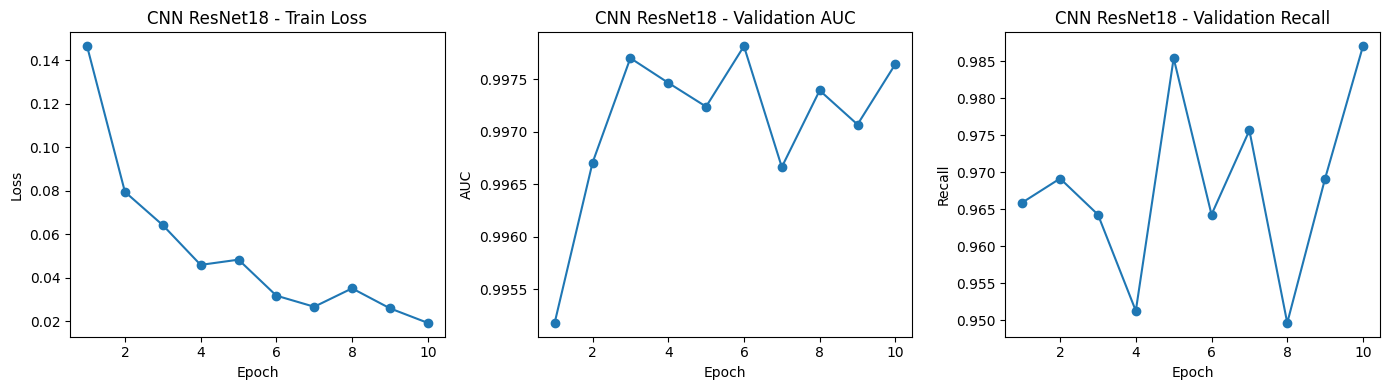

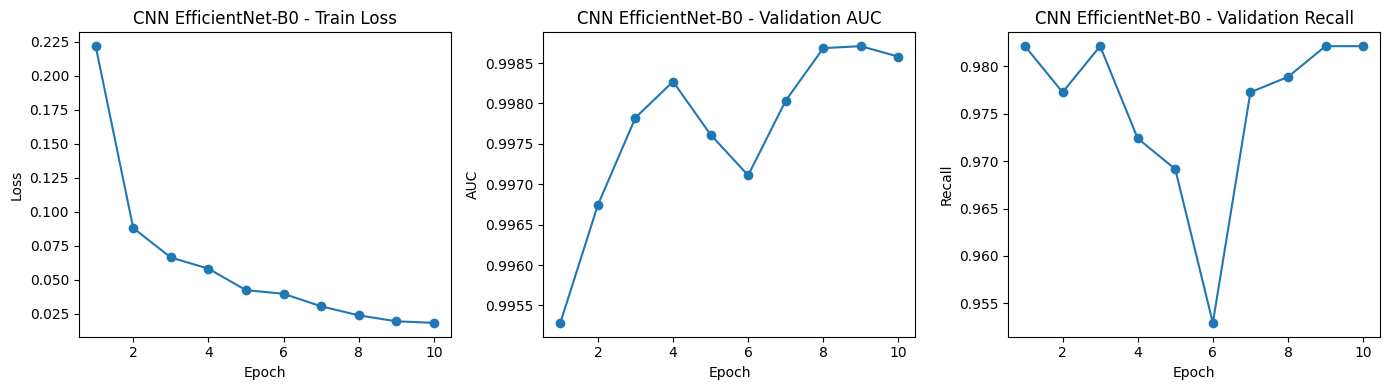

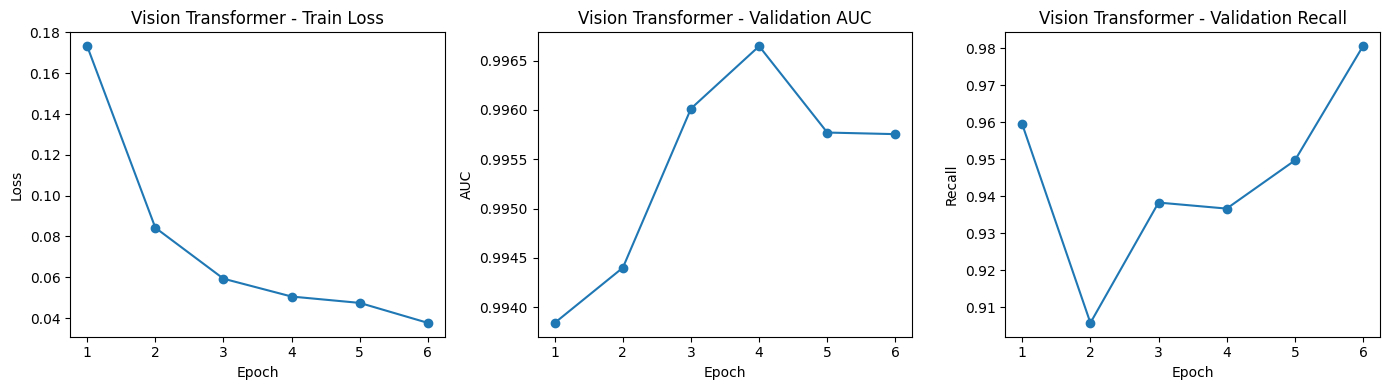

In [35]:
def plot_training_history(history, title):
    """
    Plot training loss and validation metrics.
    These plots help verify that the model converges and does not behave randomly.
    """
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], marker="o")
    plt.title(f"{title} - Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["val_auc"], marker="o")
    plt.title(f"{title} - Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_recall"], marker="o")
    plt.title(f"{title} - Validation Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")

    plt.tight_layout()
    plt.show()

plot_training_history(cnn_history, "CNN ResNet18")
plot_training_history(efficientnet_history, "CNN EfficientNet-B0")
plot_training_history(vit_history, "Vision Transformer")

## 15. Final comparison table

In [36]:
comparison_rows = []

# Autoencoder from previous section.
# Use existing variables from AE section: test_y, anomaly_scores, ae_preds.
try:
    comparison_rows.append({
        "Model": "Autoencoder Anomaly Detection",
        "Type": "One-class / anomaly detection",
        "AUC": roc_auc_score(test_y, anomaly_scores),
        "Precision": precision_score(test_y, ae_preds, zero_division=0),
        "Recall": recall_score(test_y, ae_preds, zero_division=0),
        "F1": f1_score(test_y, ae_preds, zero_division=0),
        "Threshold": threshold
    })
except Exception as e:
    print("Skipping Autoencoder row because AE variables were not found:", e)


comparison_rows.extend([
    {
        "Model": "CNN ResNet18",
        "Type": "Supervised CNN",
        "AUC": cnn_test_metrics["auc"],
        "Precision": cnn_test_metrics["precision"],
        "Recall": cnn_test_metrics["recall"],
        "F1": cnn_test_metrics["f1"],
        "Threshold": cnn_best_threshold
    },
    {
        "Model": "CNN EfficientNet-B0",
        "Type": "Supervised CNN",
        "AUC": efficientnet_test_metrics["auc"],
        "Precision": efficientnet_test_metrics["precision"],
        "Recall": efficientnet_test_metrics["recall"],
        "F1": efficientnet_test_metrics["f1"],
        "Threshold": efficientnet_best_threshold
    },
    {
        "Model": "Vision Transformer",
        "Type": "Supervised ViT",
        "AUC": vit_test_metrics["auc"],
        "Precision": vit_test_metrics["precision"],
        "Recall": vit_test_metrics["recall"],
        "F1": vit_test_metrics["f1"],
        "Threshold": vit_best_threshold
    }
])

results_df = pd.DataFrame(comparison_rows)
results_df

,Model,Type,AUC,Precision,Recall,F1,Threshold
0,Autoencoder Anomaly Detection,One-class / anomaly detection,0.510530,0.625000,0.064103,0.116279,1.928156
1,CNN ResNet18,Supervised CNN,0.949091,0.742366,0.997436,0.851204,0.055000
2,CNN EfficientNet-B0,Supervised CNN,0.957380,0.761252,0.997436,0.863485,0.175000
3,Vision Transformer,Supervised ViT,0.957736,0.795501,0.997436,0.885097,0.050000


## 16. Final comparison plots

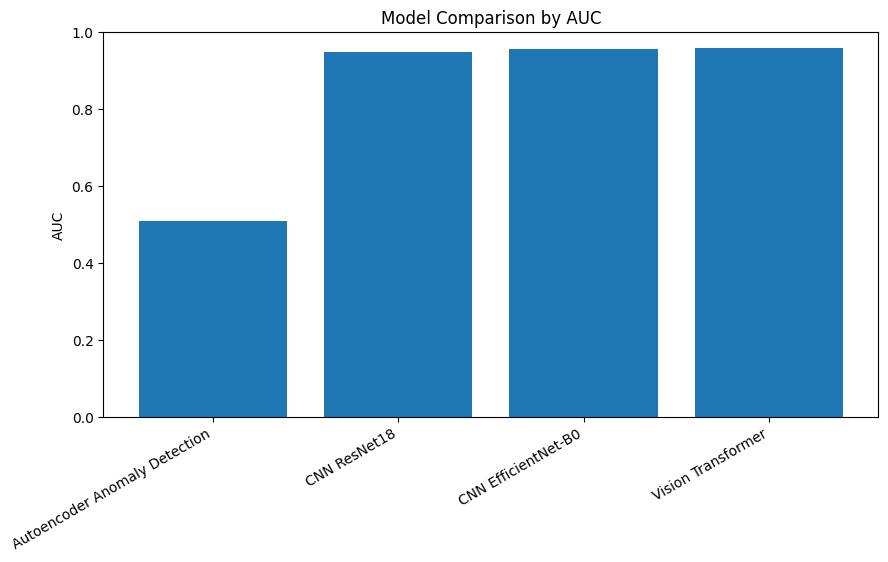

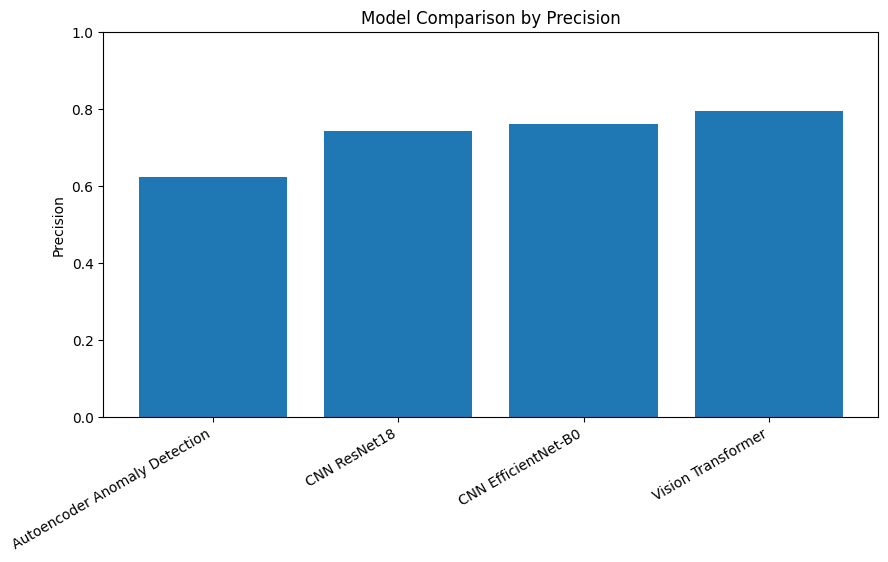

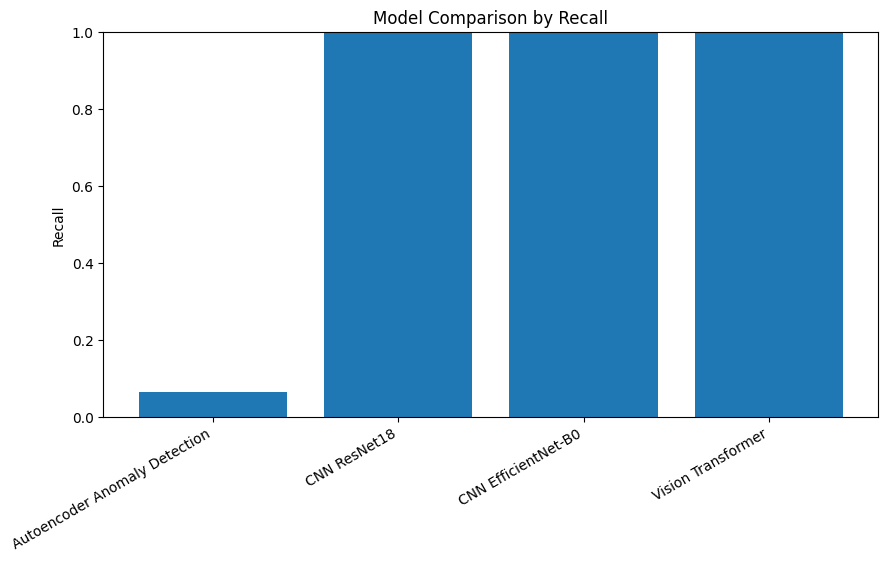

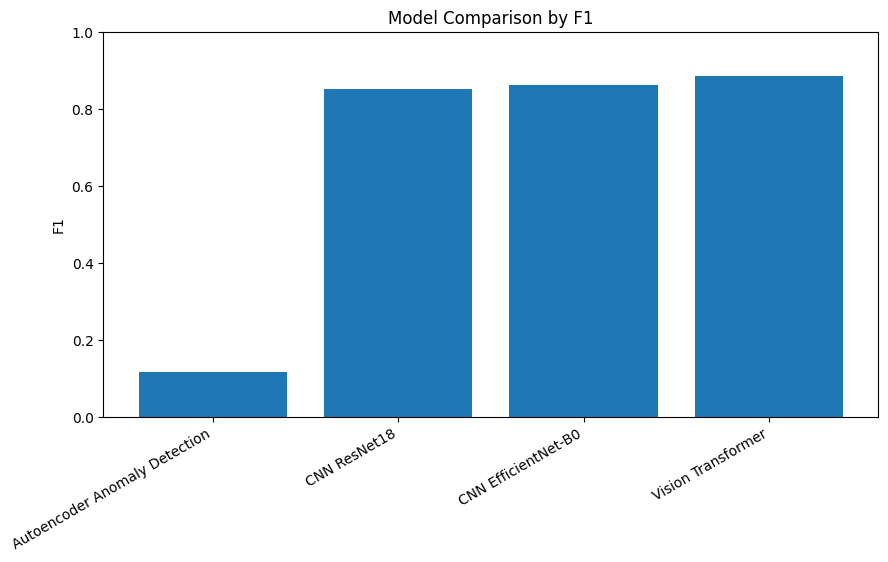

In [38]:
metrics_to_plot = ["AUC", "Precision", "Recall", "F1"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    plt.bar(results_df["Model"], results_df[metric])
    plt.ylabel(metric)
    plt.title(f"Model Comparison by {metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.show()

## 17. ROC curves

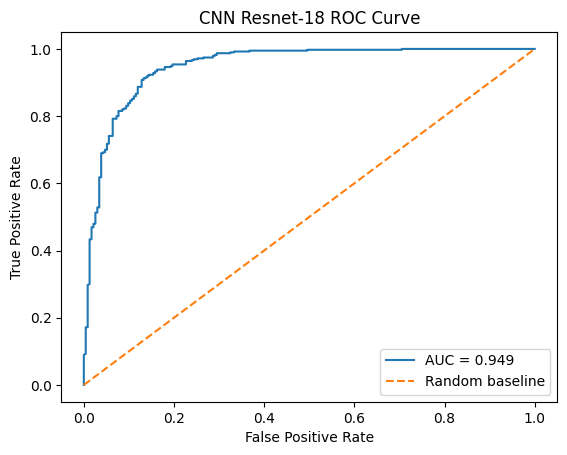

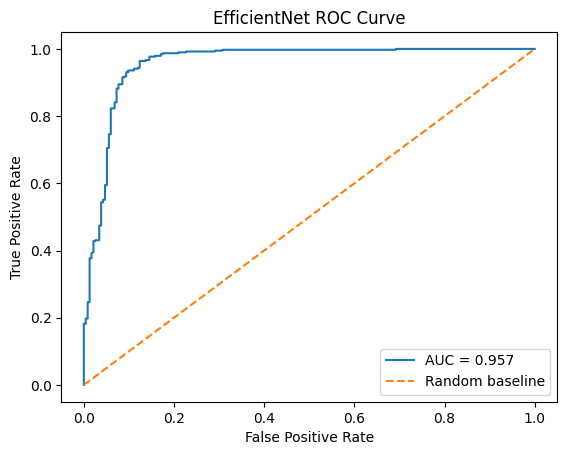

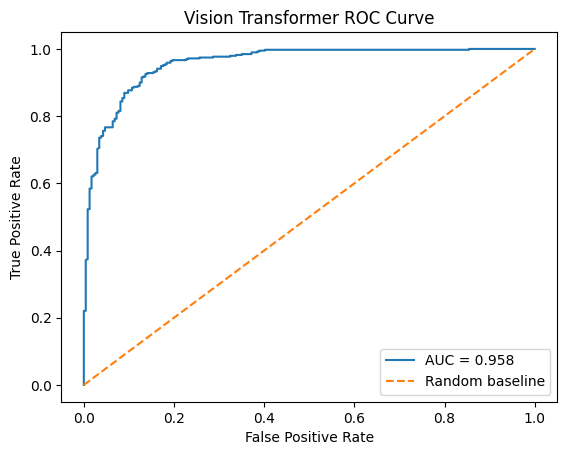

In [39]:
def plot_roc_curve(y_true, probs, title):
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle='--', label='Random baseline')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_roc_curve(cnn_true, cnn_probs, "CNN Resnet-18 ROC Curve")
plot_roc_curve(eff_true, eff_probs, "EfficientNet ROC Curve")
plot_roc_curve(vit_true, vit_probs, "Vision Transformer ROC Curve")

## 18. Precision-Recall curves

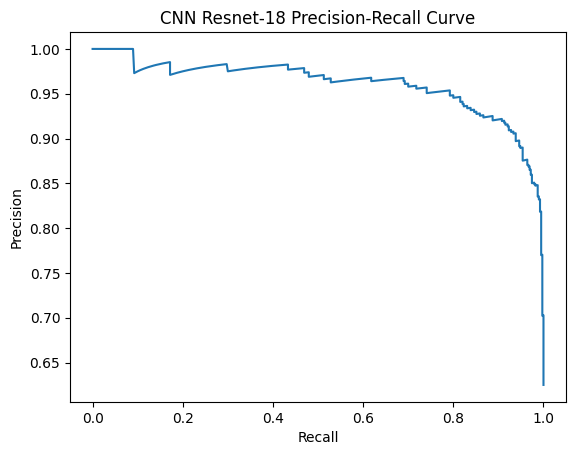

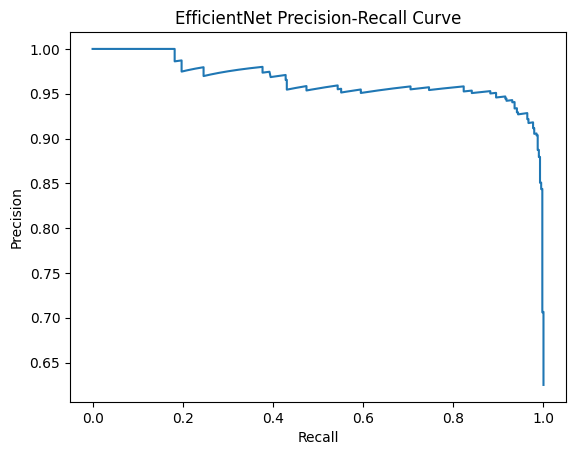

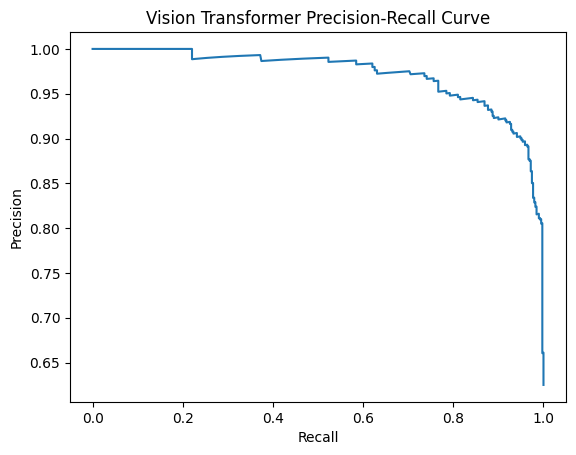

In [40]:
def plot_pr_curve(y_true, probs, title):
    precision, recall, _ = precision_recall_curve(y_true, probs)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.show()

plot_pr_curve(cnn_true, cnn_probs, "CNN Resnet-18 Precision-Recall Curve")
plot_pr_curve(eff_true, eff_probs, "EfficientNet Precision-Recall Curve")
plot_pr_curve(vit_true, vit_probs, "Vision Transformer Precision-Recall Curve")

## 19. Probability distribution plots

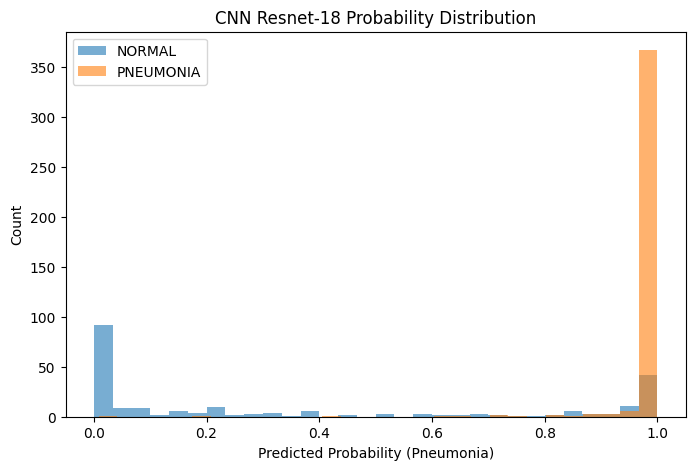

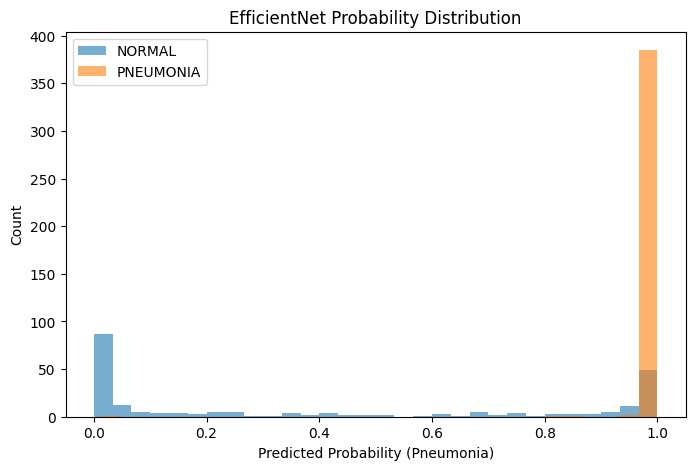

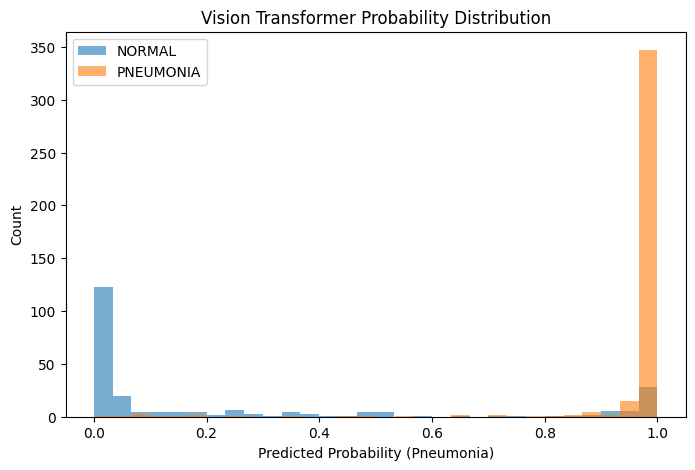

In [43]:
def plot_prob_distribution(probs, labels, title):
    """
    Shows how well the model separates NORMAL and PNEUMONIA samples.
    Good separation means NORMAL is mostly near 0 and PNEUMONIA mostly near 1.
    """
    plt.figure(figsize=(8,5))
    plt.hist(probs[labels==0], bins=30, alpha=0.6, label="NORMAL")
    plt.hist(probs[labels==1], bins=30, alpha=0.6, label="PNEUMONIA")
    plt.xlabel("Predicted Probability (Pneumonia)")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.show()

plot_prob_distribution(cnn_probs, cnn_true, "CNN Resnet-18 Probability Distribution")
plot_prob_distribution(eff_probs, eff_true, "EfficientNet Probability Distribution")
plot_prob_distribution(vit_probs, vit_true, "Vision Transformer Probability Distribution")